In [2]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd

input_path = "../cleaned_data/swimming.csv"
df_swim = pd.read_csv(input_path)

features = [
    "Distance",
    "Stroke",
    "Gender",
    "Relay?",
    "Year",
    "Team",
    "Experience",
    "Previous_Best",
    "Previous_Average"
]

target = "Results"

# Remove rows that don't have a target
df_model = df_swim.dropna(subset=[target]).copy()

In [3]:
train = df_model[df_model["Year"] < 2016]
test = df_model[df_model["Year"] >= 2016]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

categorical_features = [
    "Stroke",
    "Gender",
    "Relay?",
    "Team"
]

In [4]:
model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    loss_function="MAE",
    eval_metric="MAE",
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test)
)

0:	learn: 115.6119733	test: 109.0392129	best: 109.0392129 (0)	total: 198ms	remaining: 1m 18s
100:	learn: 6.2179108	test: 17.4326271	best: 17.4326271 (100)	total: 3.19s	remaining: 9.45s
200:	learn: 3.9743609	test: 15.0804409	best: 15.0804409 (200)	total: 5.82s	remaining: 5.76s
300:	learn: 3.2545499	test: 14.7262635	best: 14.7262635 (300)	total: 8.23s	remaining: 2.71s
399:	learn: 3.0149243	test: 14.6369989	best: 14.6369989 (399)	total: 10.8s	remaining: 0us

bestTest = 14.63699893
bestIteration = 399



CatBoostRegressor(depth=6, eval_metric='MAE', iterations=400, learning_rate=0.05, loss_function='MAE', verbose=100)

In [5]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

print(f"MAE: {mae:.3f} seconds")

MAE: 14.637 seconds


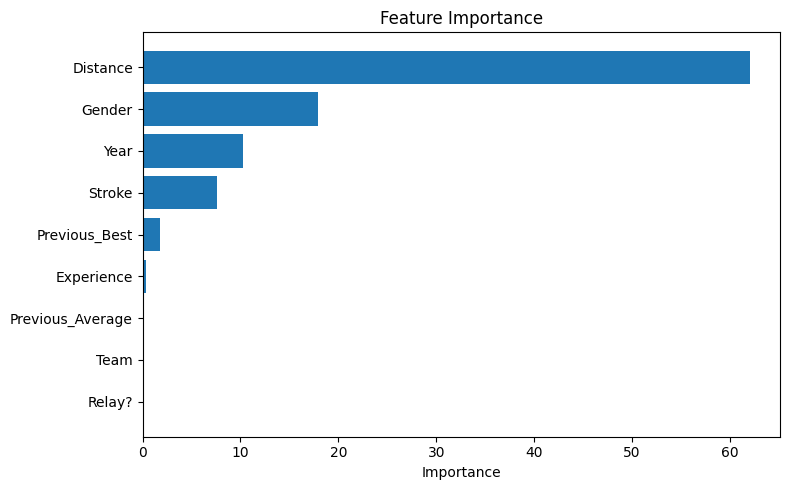

In [6]:

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.get_feature_importance()
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Keep the latest race of each athlete
future = (
    df_model.sort_values("Year")
            .groupby("Athlete")
            .tail(1)
            .copy()
)

# Predict for the next Olympics
future["Year"] = 2028

future["Predicted_Time"] = model.predict(future[features])

events = [
    (50, "Freestyle"),
    (100, "Freestyle"),
    (200, "Butterfly"),
    (100, "Backstroke"),
    (200, "Breaststroke")
]

def predict_top_ten(distance : str, stroke : str):
    subset = future[
        (future["Distance"] == distance) &
        (future["Stroke"] == stroke)
    ].copy()

    subset["Predicted_Time"] = model.predict(subset[features])

    # Sort by predicted time, then keep only the fastest athlete per team
    subset = (
        subset.sort_values("Predicted_Time")
              .drop_duplicates(subset="Team", keep="first")
    )

    return subset

for distance, stroke in events:

    subset = predict_top_ten(distance, stroke)

    print(f"\n{distance}m {stroke}")
    print(
        subset[["Athlete", "Team", "Predicted_Time"]]
              .head(10)
    )


50m Freestyle
                  Athlete Team  Predicted_Time
3299         Thom De Boer  NED       21.414920
2297       Matthew Biondi  USA       21.420140
2205   Mark Andrew Foster  GBR       21.459770
1907   Kristian Gkolomeev  GRE       21.470700
2561         Nils Rudolph  GER       21.493390
3439   Vladimir Tkachenko  URS       21.549894
2055      Lorenzo Zazzeri  ITA       21.555416
429           Brett Hawke  AUS       21.567730
558     Cesar Cielo Filho  BRA       21.575993
606   Christophe Kalfayan  FRA       21.586389

100m Freestyle
                        Athlete Team  Predicted_Time
2519              Nathan Adrian  USA       46.990900
2388     Michael Vincent Wenden  AUS       47.433509
2866   Robert Bilsland Mcgregor  GBR       47.482948
3331               Tommy Werner  SWE       47.529931
3422              Vladimir Bure  URS       47.569209
72                Aldo Eminente  FRA       47.593652
1111            Gennady Prigoda  EUN       47.713237
2140         Marcello Guardu